# Create single G1 model

**Goal:**
Create a model that uses the same G1 for mother and daughter cells. The daughter cells will have a different time interval, but the constructed H should use the same columns for both mothers and daughters. The config and/or the calcH will need to be modified.


**Notes:**
- Retrieiving indices and timepoints by phase and branch will need to be changed for DG1
    - The indices will match CG1
    - The timepoints will be from the config
    

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


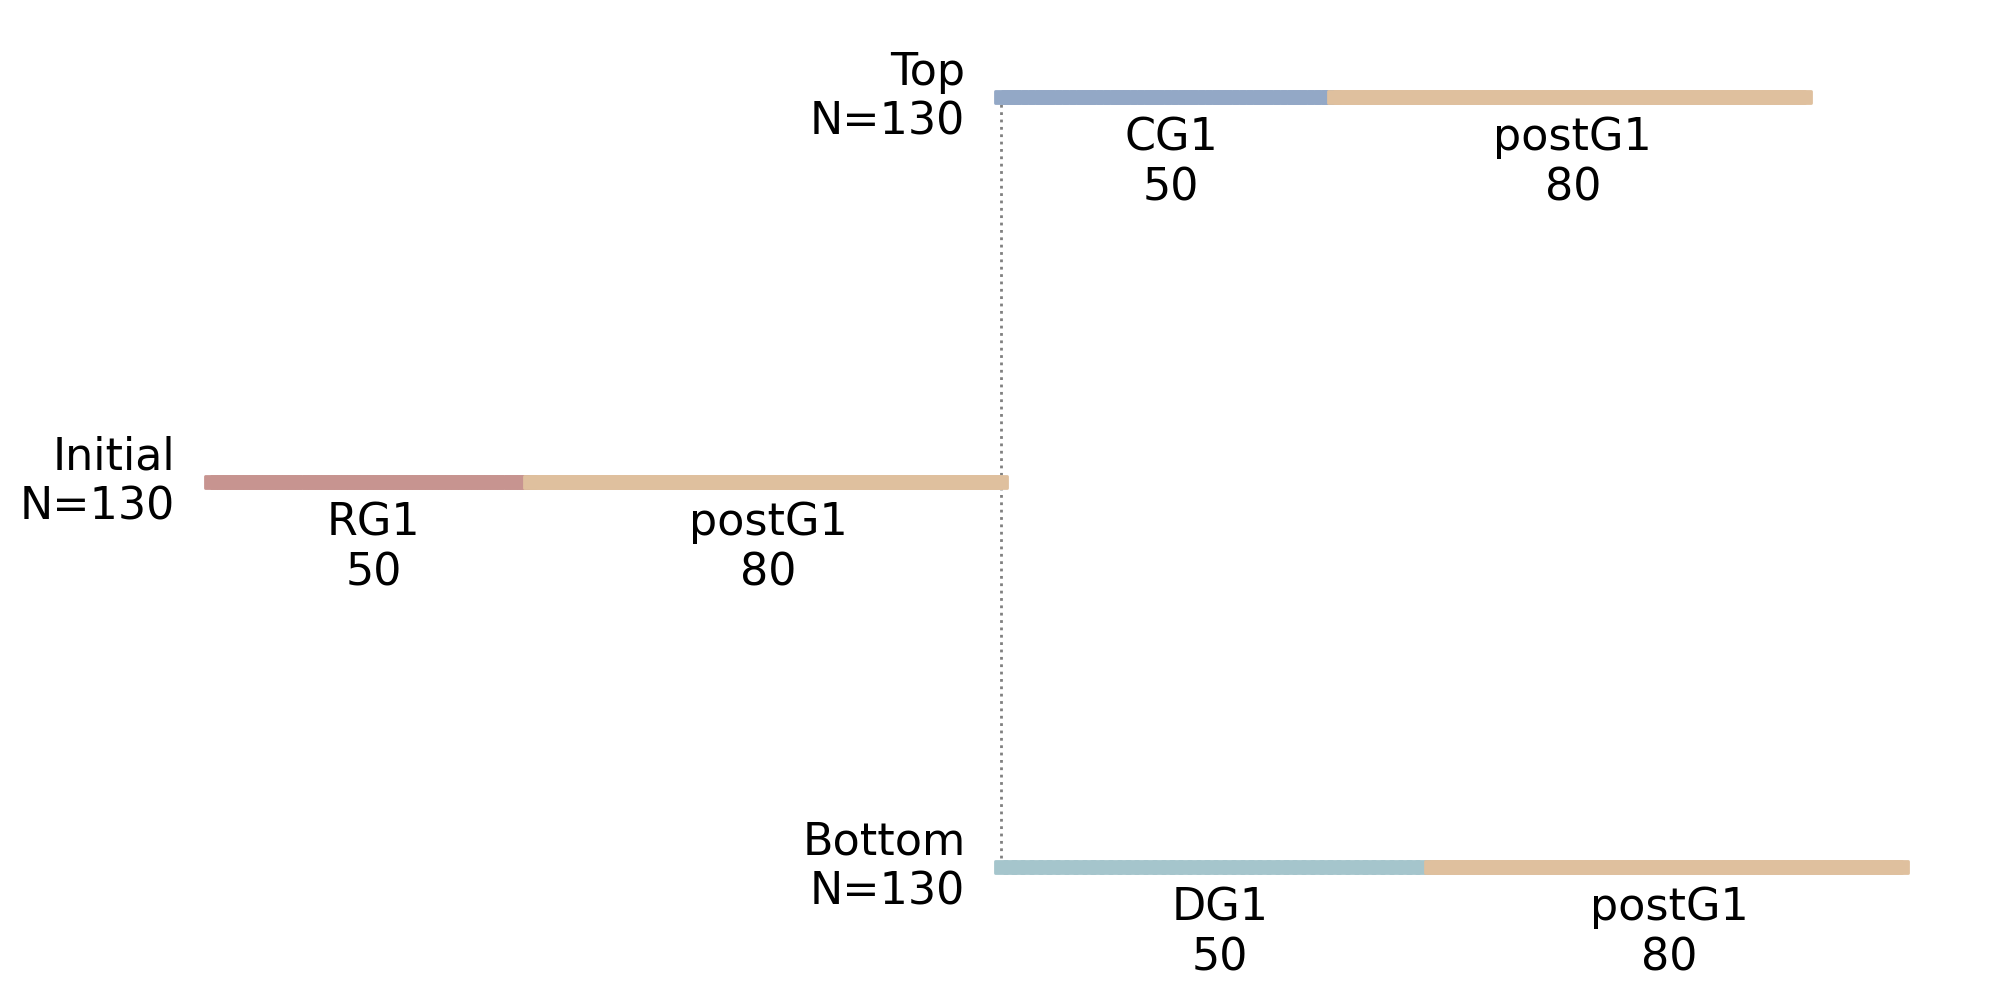

In [2]:
from src.ModelFile import ModelFile

model_file_loaded = ModelFile()
model_file_loaded.load_model('models/yl_cell_cycle/wt1_rg1.28.label')
model_file_loaded.plot_model()

In [88]:
from src.calcH_single_g1 import calcH
from src.single_G1_config import load_single_g1_config

config1 = load_single_g1_config(1)
H, Hpositions = calcH(config1.intervals_wt1, config1.WT1_TIMEPOINTS)

In [125]:
from src.model import Model

model = Model(config1, 'CLB2')

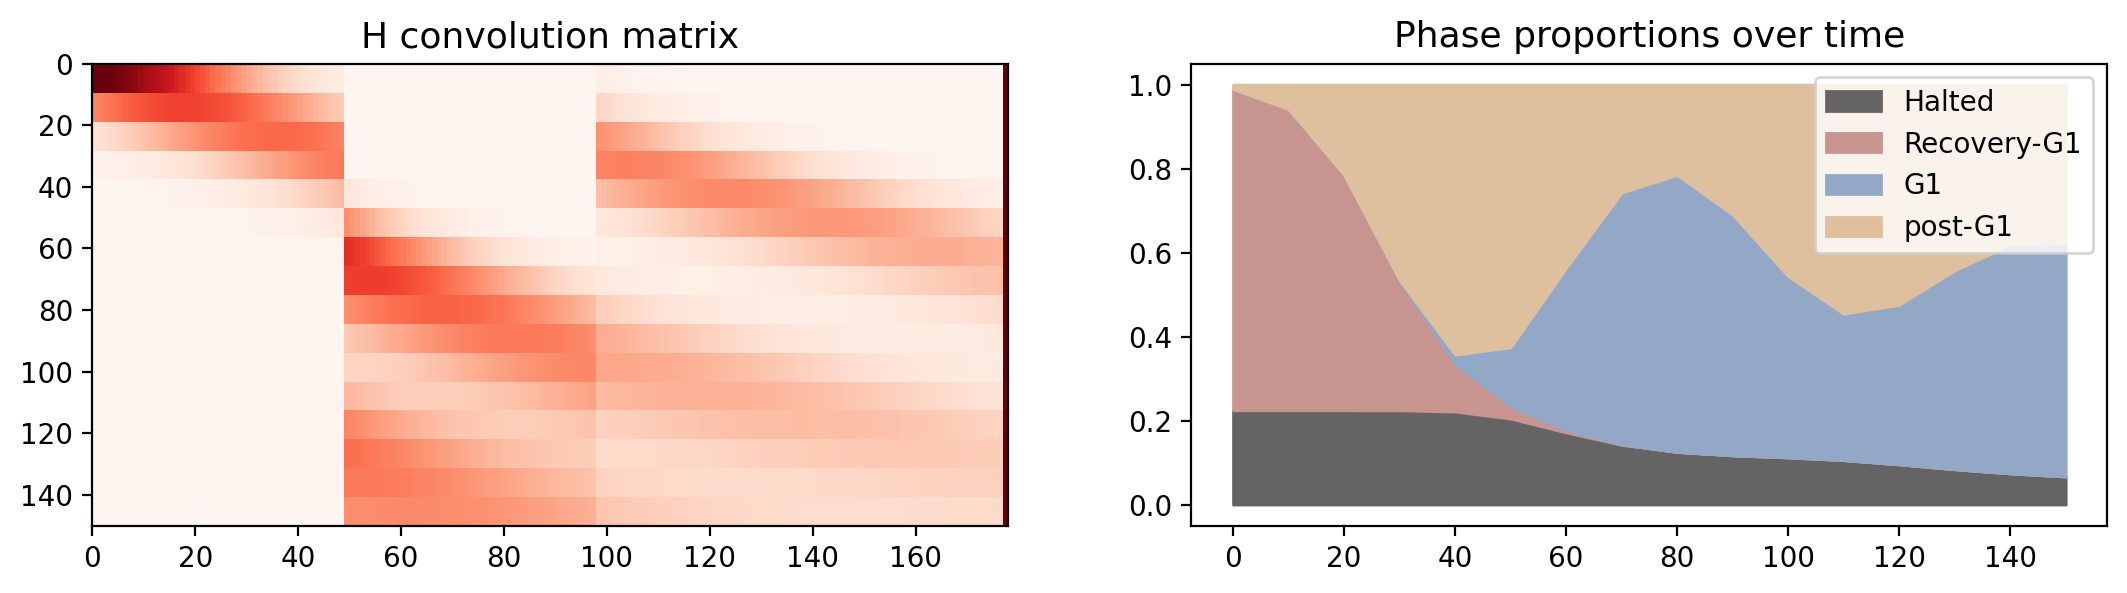

In [128]:
from src.single_G1_config import plot_H

plot_H(model.config, model.H)

In [132]:
model.deconvolve_find_optimal_gamma()

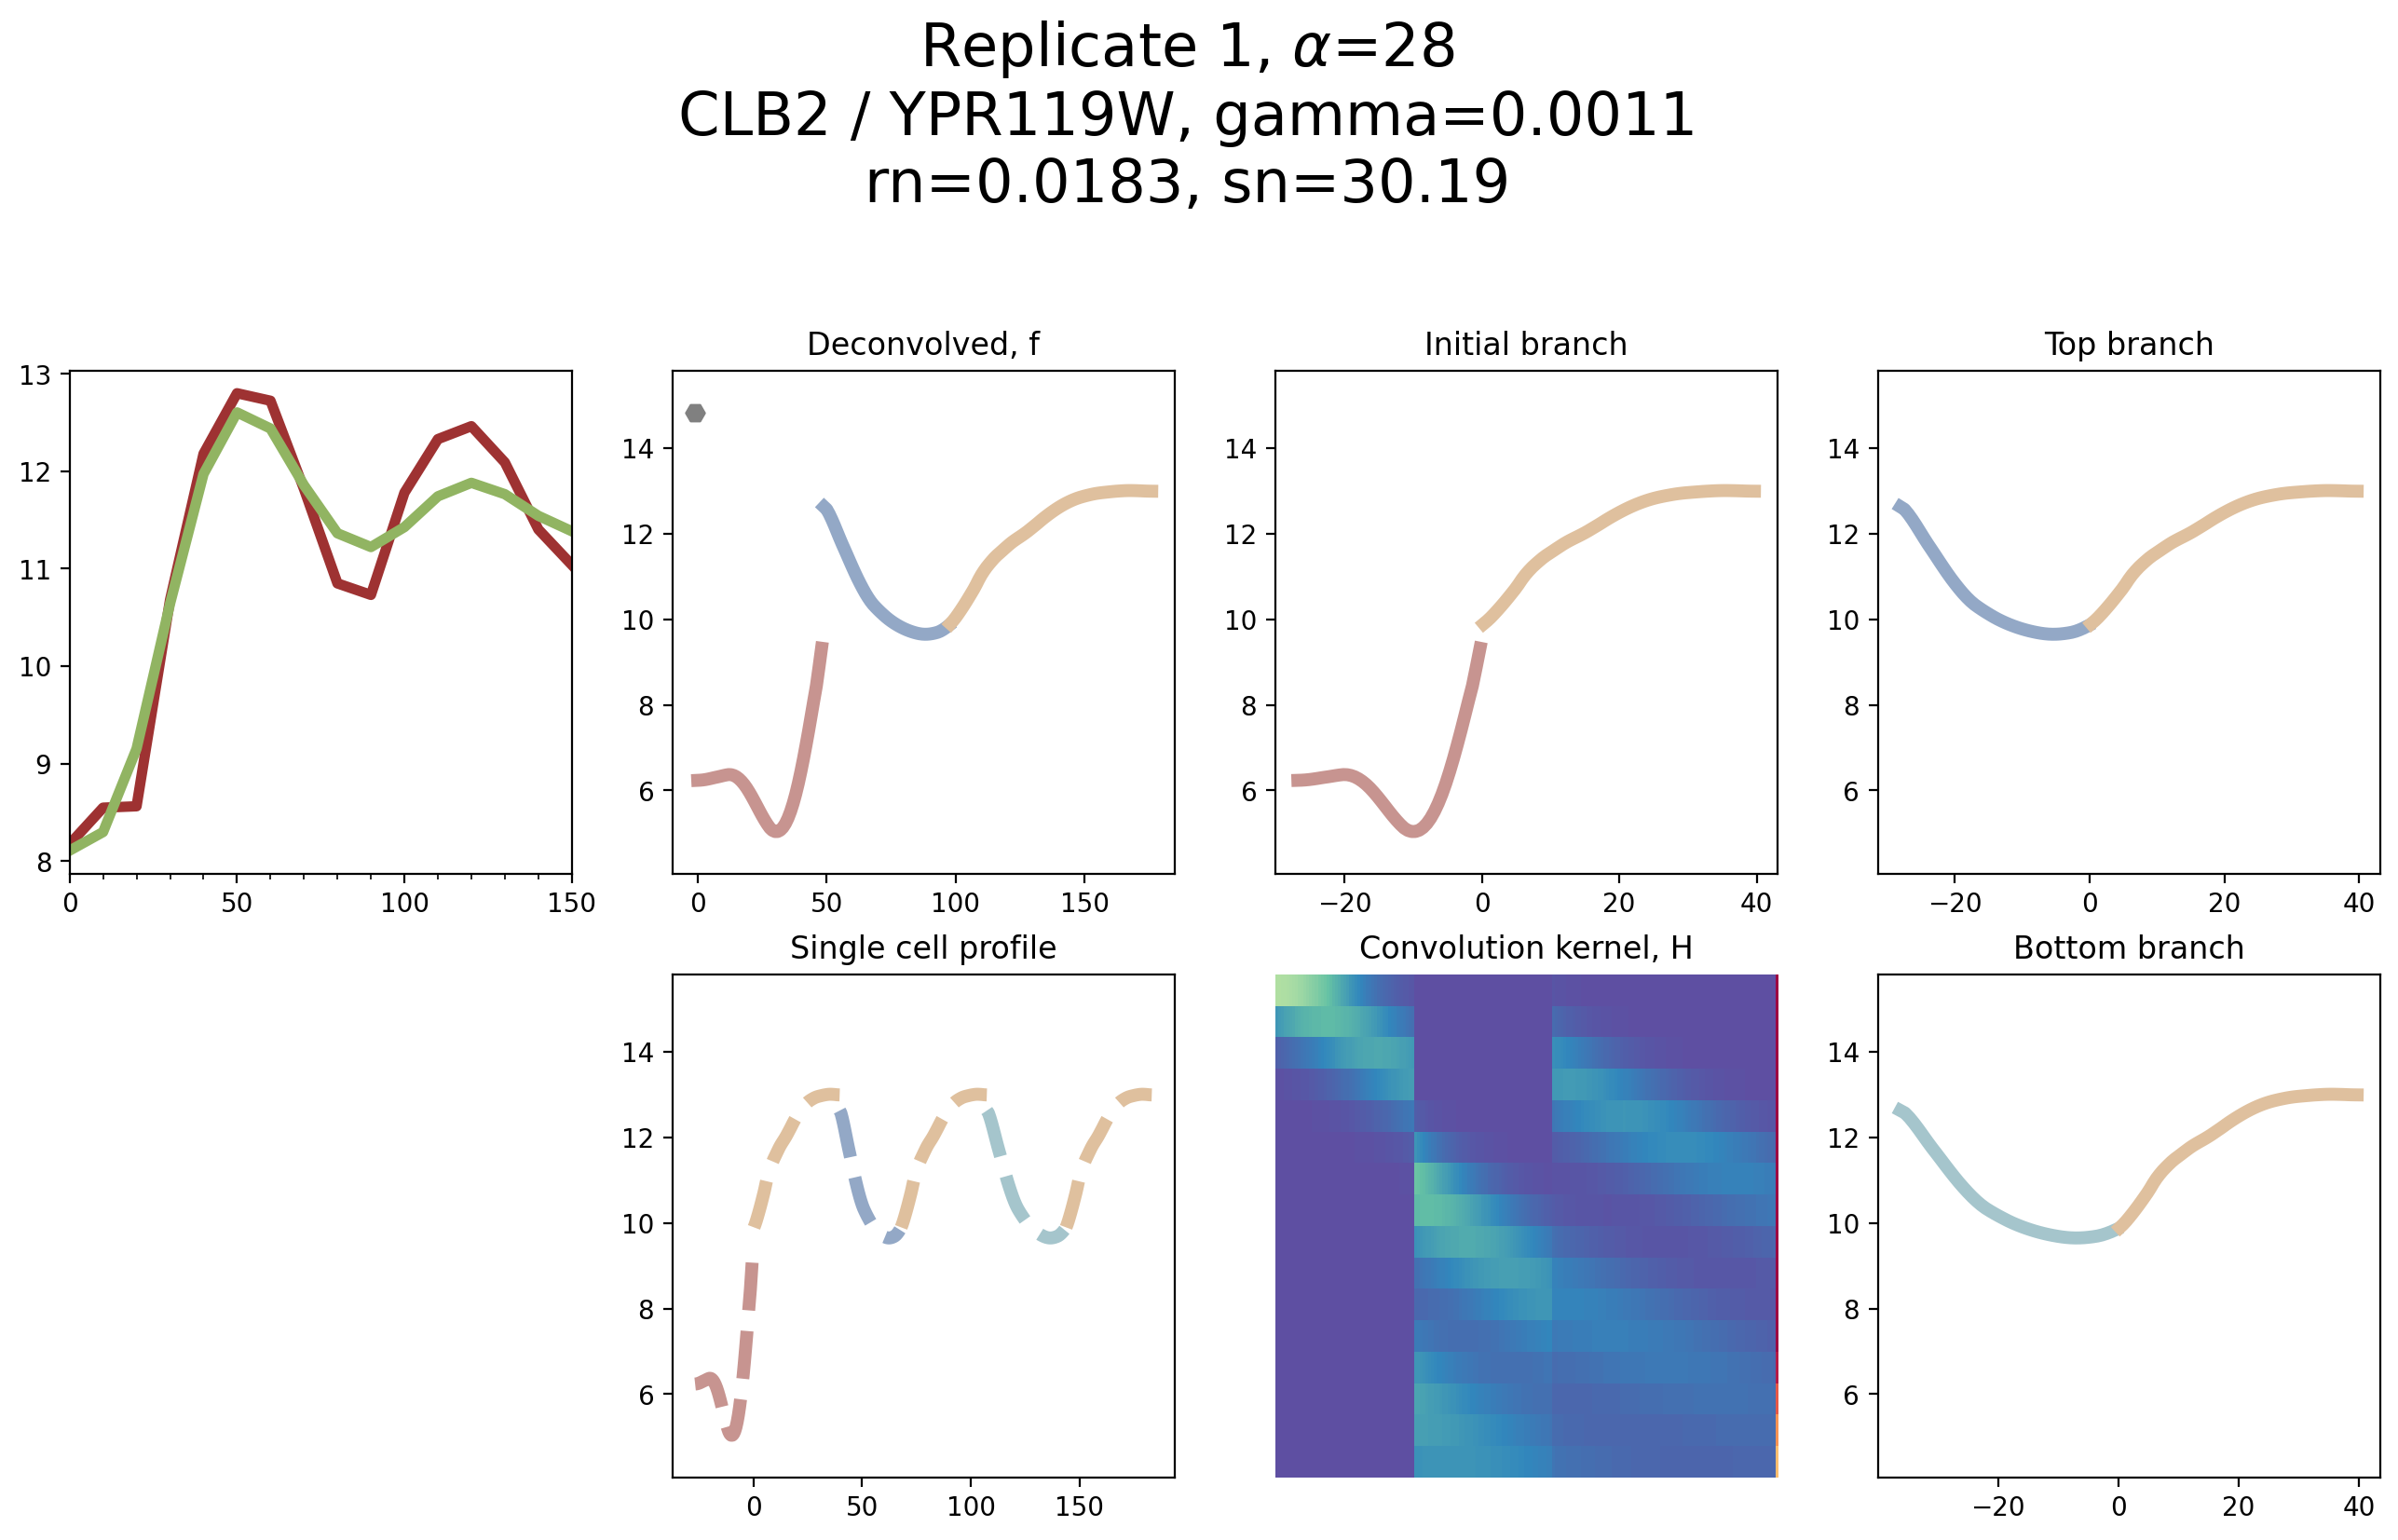

In [134]:
fig = model.plot_deconvolved_gene()

In [135]:
from src.chromatin_model import ChromatinModel

chrom_model = ChromatinModel(config1)
chrom_model.load_mnase_gene('CLB2')

Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.


In [136]:
chrom_model.create_deconvolution_bins()

In [ ]:
chrom_model.deconvolve(0.008)

Deconvolving with gamma=0.006
0/340 - 00:00:00.133
100/340 - 00:00:10.660


In [ ]:
fig = chrom_model.create_deconvolution_plots_abbreviated_flipped(vmax=30)